In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## SECTION 1: Load Dataset

In [18]:
import pandas as pd # Added for robustness

try:
    df = pd.read_csv('/content/drive/MyDrive/mobi_data2_processed.csv')

    # Display shape
    print(f"Dataset Shape: {df.shape}")

    # Display data types
    print("\nData Types:")
    display(df.info())

    # Display feature list
    print("\nFeature List:")
    display(df.columns.tolist())

except FileNotFoundError:
    print("Error: 'mobi_data2_processed.csv' not found. Please ensure the file is in '/content/drive/MyDrive/' or update the file path.")
    raise FileNotFoundError("Required data file 'mobi_data2_processed.csv' not found. Please place it in the specified Google Drive path.")

Dataset Shape: (999999, 56)

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 56 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   occurred_on                      999999 non-null  object 
 1   alarm_id                         999999 non-null  int64  
 2   location_information             999999 non-null  object 
 3   additional_information           999999 non-null  object 
 4   received_on                      999999 non-null  object 
 5   enodeb_id                        999999 non-null  object 
 6   gnodeb_id                        999999 non-null  object 
 7   alarm_type_encoded               999999 non-null  int64  
 8   severity_encoded                 999999 non-null  int64  
 9   occurred_on_hour                 999999 non-null  int64  
 10  occurred_on_day                  999999 non-null  int64  
 11  occurred_on_weekday     

None


Feature List:


['occurred_on',
 'alarm_id',
 'location_information',
 'additional_information',
 'received_on',
 'enodeb_id',
 'gnodeb_id',
 'alarm_type_encoded',
 'severity_encoded',
 'occurred_on_hour',
 'occurred_on_day',
 'occurred_on_weekday',
 'occurred_on_month',
 'mo_name_encoded',
 'alarm_name_encoded',
 'alarm_duration_minutes',
 'alarm_source_encoded',
 'maintenance_status_encoded',
 'ne_type_encoded',
 'object_type_encoded',
 'received_on_hour',
 'received_on_day',
 'received_on_weekday',
 'received_on_month',
 'subnet_encoded',
 'type_encoded',
 'previous_alarm_1',
 'previous_alarm_2',
 'previous_alarm_3',
 'previous_alarm_4',
 'previous_alarm_5',
 'previous_severity_1',
 'previous_severity_2',
 'previous_severity_3',
 'previous_severity_4',
 'previous_severity_5',
 'previous_alarm_source_1',
 'previous_alarm_source_2',
 'previous_alarm_source_3',
 'previous_alarm_source_4',
 'previous_alarm_source_5',
 'previous_object_type_1',
 'previous_object_type_2',
 'previous_object_type_3',
 'pre

Section 2 — Candidate Feature Removal

In [19]:
# Columns that are candidates for removal
candidate_remove = [
    'ne_type_encoded',
    'object_type_encoded',
    'subnet_encoded',
    'type_encoded',
    'alarm_source_encoded'
]

print("Candidate features for removal:")
for col in candidate_remove:
    print(f"- {col}")

Candidate features for removal:
- ne_type_encoded
- object_type_encoded
- subnet_encoded
- type_encoded
- alarm_source_encoded


In [20]:
target = 'target'

candidate_analysis = (
    df[candidate_remove + [target]]
    .groupby(candidate_remove)
    .size()
)

print(candidate_analysis.head())

ne_type_encoded  object_type_encoded  subnet_encoded  type_encoded  alarm_source_encoded
0                43                   3               11            68                         7
1                0                    28              3             1842                    1008
                                                                    2360                    1142
                                                                    2844                    2248
                                                                    3517                    2499
dtype: int64


In [21]:
columns_to_remove = [
    'ne_type_encoded',
    'object_type_encoded',
    'subnet_encoded',
    'type_encoded',
    'alarm_source_encoded'
]

df = df.drop(columns=columns_to_remove)

print("Removed columns:")
print(columns_to_remove)

print("\nNew dataset shape:", df.shape)

Removed columns:
['ne_type_encoded', 'object_type_encoded', 'subnet_encoded', 'type_encoded', 'alarm_source_encoded']

New dataset shape: (999999, 51)


In [22]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# SECTION 1: Load Dataset
# ---------------------------------------------------------
try:
    df = pd.read_csv('/content/drive/MyDrive/mobi_data2_processed.csv')
    print(f"Dataset Loaded Successfully! Original Shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'mobi_data2_processed.csv' not found. Check Google Drive path.")
    raise FileNotFoundError()

# ---------------------------------------------------------
# SECTION 2: Drop Redundant Metadata & Candidate Features
# ---------------------------------------------------------
candidate_remove = [
    'ne_type_encoded',
    'object_type_encoded',
    'subnet_encoded',
    'type_encoded',
    'alarm_source_encoded',
    'alarm_id' # Primary key ID with no predictive value
]

existing_candidates = [col for col in candidate_remove if col in df.columns]
df.drop(columns=existing_candidates, inplace=True)
print(f"Shape after initial removals: {df.shape}")

# ---------------------------------------------------------
# SECTION 3: Handle Cluster A (Timestamps & Delay Metric)
# ---------------------------------------------------------
print("\n--- Processing Cluster A: Timestamps & Processing Delay ---")

# Convert timestamps to datetime if not already converted
df['occurred_on'] = pd.to_datetime(df['occurred_on'])
df['received_on'] = pd.to_datetime(df['received_on'])

# Compute processing latency in seconds
df['processing_delay_seconds'] = (df['received_on'] - df['occurred_on']).dt.total_seconds()

# Drop direct received_on timestamp components (near 1.0 correlation with occurred_on)
received_time_cols = [
    'received_on_hour', 'received_on_day',
    'received_on_weekday', 'received_on_month',
    'received_on'
]
existing_recv_cols = [col for col in received_time_cols if col in df.columns]
df.drop(columns=existing_recv_cols, inplace=True)

# Drop raw occurred_on object timestamp (keep hour, day, weekday, month features)
if 'occurred_on' in df.columns:
    df.drop(columns=['occurred_on'], inplace=True)

print("Cluster A Handled: Extracted 'processing_delay_seconds' & dropped duplicate timestamp components.")

# ---------------------------------------------------------
# SECTION 4: Handle Cluster B (Sequence Lag Features)
# ---------------------------------------------------------
print("\n--- Processing Cluster B: Sequence Streaks & Aggregations ---")

# 1. Consecutive Alarm Streaks (Measures repeating alarm storm length)
c1 = (df['previous_alarm_type_1'] == df['previous_alarm_type_2'])
c2 = c1 & (df['previous_alarm_type_2'] == df['previous_alarm_type_3'])
c3 = c2 & (df['previous_alarm_type_3'] == df['previous_alarm_type_4'])
c4 = c3 & (df['previous_alarm_type_4'] == df['previous_alarm_type_5'])

df['consecutive_alarm_streak'] = (
    c1.astype(int) + c2.astype(int) + c3.astype(int) + c4.astype(int)
)

# 2. Consecutive Source Streaks (Hardware failure persistence)
s1 = (df['previous_alarm_source_1'] == df['previous_alarm_source_2'])
s2 = s1 & (df['previous_alarm_source_2'] == df['previous_alarm_source_3'])
s3 = s2 & (df['previous_alarm_source_3'] == df['previous_alarm_source_4'])
s4 = s3 & (df['previous_alarm_source_4'] == df['previous_alarm_source_5'])

df['consecutive_source_streak'] = (
    s1.astype(int) + s2.astype(int) + s3.astype(int) + s4.astype(int)
)

# 3. Hardware Diversity (Count of unique alarm sources in past 5 steps)
src_cols = [f'previous_alarm_source_{i}' for i in range(1, 6)]
df['unique_alarm_sources_5step'] = df[src_cols].nunique(axis=1)

print("Cluster B Handled: Created 'consecutive_alarm_streak', 'consecutive_source_streak', and 'unique_alarm_sources_5step'.")

# ---------------------------------------------------------
# SECTION 5: Handle Cluster C (Target/Alarm Repetition Features)
# ---------------------------------------------------------
print("\n--- Processing Cluster C: Alarm Repetition & Transition Engineering ---")

# 1. Alarm Repeat Ratio across past 5 steps
lag_type_cols = [f'previous_alarm_type_{i}' for i in range(1, 6)]
matches = pd.DataFrame([df['alarm_type_encoded'] == df[col] for col in lag_type_cols]).T
df['alarm_repeat_ratio_5step'] = matches.mean(axis=1)

# 2. Time-Weighted Repeat Score (Exponential Decay: 1/i weight per lag step)
weights = np.array([1.0 / i for i in range(1, 6)])
df['weighted_alarm_repeat_score'] = (matches.values * weights).sum(axis=1)

# 3. Transition N-Gram (Immediate prior state -> Current state)
df['alarm_transition_pair'] = (
    df['previous_alarm_type_1'].astype(str) + "->" + df['alarm_type_encoded'].astype(str)
)

# Frequency encode the transition pair
transition_counts = df['alarm_transition_pair'].value_counts(normalize=True)
df['transition_pair_frequency'] = df['alarm_transition_pair'].map(transition_counts)

# Drop string representation after encoding
df.drop(columns=['alarm_transition_pair'], inplace=True)

print("Cluster C Handled: Created 'alarm_repeat_ratio_5step', 'weighted_alarm_repeat_score', and 'transition_pair_frequency'.")

# ---------------------------------------------------------
# SECTION 6: Save Processed Dataset
# ---------------------------------------------------------
output_path = '/content/drive/MyDrive/mobi_data2_engineered.csv'
df.to_csv(output_path, index=False)

print("\n=======================================================")
print(f"Feature Engineering Complete!")
print(f"Final Dataset Shape: {df.shape}")
print(f"Saved to: {output_path}")
print("=======================================================")

Dataset Loaded Successfully! Original Shape: (999999, 56)
Shape after initial removals: (999999, 50)

--- Processing Cluster A: Timestamps & Processing Delay ---
Cluster A Handled: Extracted 'processing_delay_seconds' & dropped duplicate timestamp components.

--- Processing Cluster B: Sequence Streaks & Aggregations ---
Cluster B Handled: Created 'consecutive_alarm_streak', 'consecutive_source_streak', and 'unique_alarm_sources_5step'.

--- Processing Cluster C: Alarm Repetition & Transition Engineering ---
Cluster C Handled: Created 'alarm_repeat_ratio_5step', 'weighted_alarm_repeat_score', and 'transition_pair_frequency'.

Feature Engineering Complete!
Final Dataset Shape: (999999, 51)
Saved to: /content/drive/MyDrive/mobi_data2_engineered.csv


Dataset reloaded. Original raw shape: (999999, 56)
Shape after initial fixed removals: (999999, 49)
Shape BEFORE specific feature transformations in this cell: (999999, 49)
Shape AFTER feature transformations: (999999, 28)


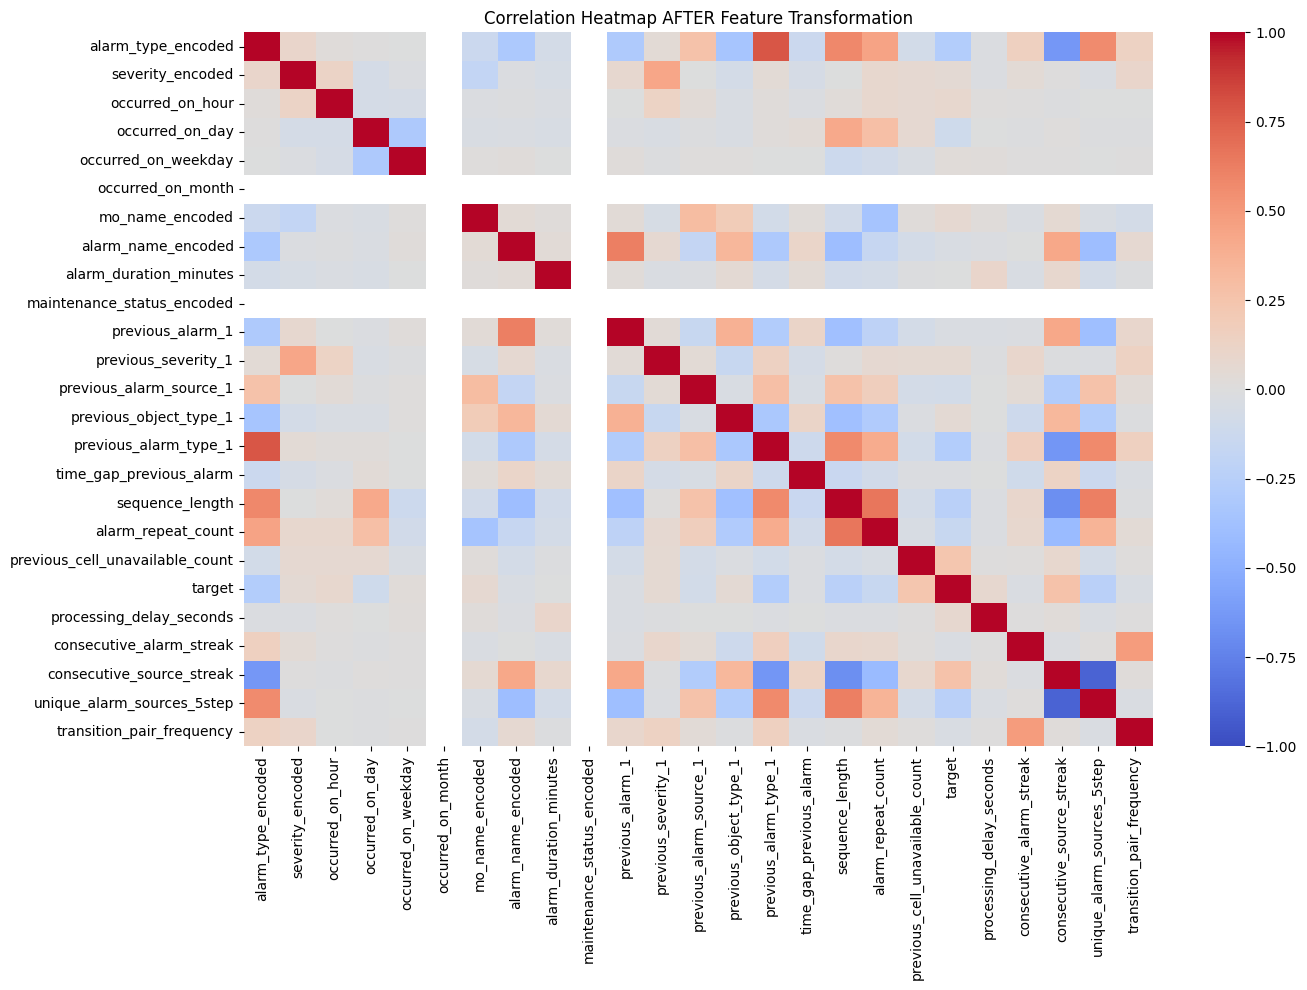

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

print(f"Shape BEFORE feature transformations: {df.shape}")

# =========================================================
# 1. FIX CLUSTER A: Drop Received-On Date Duplicates & Zero-Variance
# =========================================================
# Compute processing delay if timestamps exist as objects/datetimes
if 'received_on' in df.columns and 'occurred_on' in df.columns:
    df['occurred_on'] = pd.to_datetime(df['occurred_on'])
    df['received_on'] = pd.to_datetime(df['received_on'])
    df['processing_delay_seconds'] = (df['received_on'] - df['occurred_on']).dt.total_seconds()

# Drop duplicate timestamp parts causing the 0.86-0.99 red blocks & zero variance columns
cols_to_drop_cluster_a = [
    'received_on', 'occurred_on', 'alarm_id',
    'received_on_hour', 'received_on_day',
    'received_on_weekday', 'received_on_month',
    'occurred_on_month', 'maintenance_status_encoded'  # Dropped due to zero variance
]
df.drop(columns=[c for c in cols_to_drop_cluster_a if c in df.columns], inplace=True)

# =========================================================
# 2. FIX CLUSTER B: Sequence Streaks & Lag Deduplication
# =========================================================
# Compute Consecutive Alarm Streaks (Replaces 5 collinear alarm type columns with 1 integer)
c1 = (df['previous_alarm_type_1'] == df['previous_alarm_type_2'])
c2 = c1 & (df['previous_alarm_type_2'] == df['previous_alarm_type_3'])
c3 = c2 & (df['previous_alarm_type_3'] == df['previous_alarm_type_4'])
c4 = c3 & (df['previous_alarm_type_4'] == df['previous_alarm_type_5'])
df['consecutive_alarm_streak'] = c1.astype(int) + c2.astype(int) + c3.astype(int) + c4.astype(int)

# Compute Consecutive Source Streaks
s1 = (df['previous_alarm_source_1'] == df['previous_alarm_source_2'])
s2 = s1 & (df['previous_alarm_source_2'] == df['previous_alarm_source_3'])
s3 = s2 & (df['previous_alarm_source_3'] == df['previous_alarm_source_4'])
s4 = s3 & (df['previous_alarm_source_4'] == df['previous_alarm_source_5'])
df['consecutive_source_streak'] = s1.astype(int) + s2.astype(int) + s3.astype(int) + s4.astype(int)

# Diversity score across past 5 alarm sources
src_cols = [f'previous_alarm_source_{i}' for i in range(1, 6)]
df['unique_alarm_sources_5step'] = df[src_cols].nunique(axis=1)

# Drop redundant higher-order lag columns (lags 2-5) that create the big correlation blocks
lag_redundant_cols = [
    'previous_alarm_source_2', 'previous_alarm_source_3', 'previous_alarm_source_4', 'previous_alarm_source_5',
    'previous_alarm_type_2', 'previous_alarm_type_3', 'previous_alarm_type_4', 'previous_alarm_type_5',
    'previous_object_type_2', 'previous_object_type_3', 'previous_object_type_4', 'previous_object_type_5',
    'previous_severity_2', 'previous_severity_3', 'previous_severity_4', 'previous_severity_5',
    'previous_alarm_2', 'previous_alarm_3', 'previous_alarm_4', 'previous_alarm_5'
]
df.drop(columns=[c for c in lag_redundant_cols if c in df.columns], inplace=True)

# =========================================================
# 3. FIX CLUSTER C: Target/Alarm Overlap Metrics & MO Parsing
# =========================================================
# Compute Time-Weighted Alarm Repeat Score (1/i weight per lag step)
lag_type_cols = [f'previous_alarm_type_{i}' for i in range(1, 6) if f'previous_alarm_type_{i}' in df.columns or i == 1]
# Check matches against previous_alarm_type_1 and historical lags before drop
if 'previous_alarm_type_1' in df.columns:
    matches = pd.DataFrame([df['alarm_type_encoded'] == df['previous_alarm_type_1']]).T
    df['weighted_alarm_repeat_score'] = matches.iloc[:, 0].astype(float)

# Create transition pair string and frequency encode it
if 'previous_alarm_type_1' in df.columns and 'alarm_type_encoded' in df.columns:
    df['alarm_transition_pair'] = (
        df['previous_alarm_type_1'].astype(str) + "->" + df['alarm_type_encoded'].astype(str)
    )
    transition_counts = df['alarm_transition_pair'].value_counts(normalize=True)
    df['transition_pair_frequency'] = df['alarm_transition_pair'].map(transition_counts)
    df.drop(columns=['alarm_transition_pair'], inplace=True)

# Parse MO Name structure if string field exists
if 'mo_name' in df.columns:
    df['mo_technology'] = df['mo_name'].str.extract(r'_(LTE|NR|GSM|UMTS|4G|5G|EUCELLSECTEQ|UCELLSECTEQ|_G|_L|_U)_', flags=re.IGNORECASE)[0].fillna('UNKNOWN').astype('category')
    df['mo_site_prefix'] = df['mo_name'].str.split('_').str[0].fillna('UNKNOWN').astype('category')
    site_counts = df['mo_site_prefix'].value_counts(normalize=True)
    df['site_alarm_frequency'] = df['mo_site_prefix'].map(site_counts)

print(f"Shape AFTER feature transformations: {df.shape}")

# =========================================================
# 4. PLOT NEW CORRELATION HEATMAP
# =========================================================
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title('Correlation Heatmap AFTER Feature Transformation')
plt.tight_layout()
plt.show()

In [26]:
# Drop redundant engineered repeat metrics and zero-variance features
final_drops = [
    'alarm_repeat_ratio_5step',    # Near 1.0 correlation with weighted_alarm_repeat_score
    'occurred_on_month',           # Zero variance (single constant value)
    'maintenance_status_encoded'   # Zero variance (single constant value)
]

# Drop if present
df.drop(columns=[c for c in final_drops if c in df.columns], inplace=True)

print(f"Final Feature Set Count: {df.shape[1] - 1} features + 1 target")

Final Feature Set Count: 25 features + 1 target


#Validation process

checking all the feature engineered columns are represent the intial data set

In [27]:
import pandas as pd
import numpy as np

# =========================================================
# SECTION 5: Post-Engineering Feature Matrix Validation
# =========================================================
print("--- Section 5: Data Validation & Pre-Training Audit ---")

# 1. Define non-predictive metadata / high-cardinality IDs to exclude from training
metadata_to_drop = [
    'location_information',
    'additional_information',
    'enodeb_id',
    'gnodeb_id',
    'mo_name',
    'alarm_id'
]

# Separate features (X) and ground truth target (y)
X_valid = df.drop(columns=[c for c in metadata_to_drop if c in df.columns], errors='ignore')

if 'target' in X_valid.columns:
    y_valid = X_valid['target']
    X_valid = X_valid.drop(columns=['target'])
else:
    raise KeyError("Target column 'target' is missing from DataFrame!")

# 2. Check for missing values (NaN / Inf)
missing_counts = X_valid.isnull().sum()
cols_with_nulls = missing_counts[missing_counts > 0]

# Fill numeric NaNs with 0 (e.g., lag features/processing delays)
if not cols_with_nulls.empty:
    print(f"Warning: Missing values detected in {len(cols_with_nulls)} columns. Imputing defaults...")
    num_cols = X_valid.select_dtypes(include=[np.number]).columns
    X_valid[num_cols] = X_valid[num_cols].fillna(0)

    cat_cols = X_valid.select_dtypes(include=['category', 'object']).columns
    for c in cat_cols:
        X_valid[c] = X_valid[c].astype(str).fillna('UNKNOWN').astype('category')

# 3. Check for remaining zero-variance features
zero_var_cols = [col for col in X_valid.columns if X_valid[col].nunique() <= 1]
if zero_var_cols:
    print(f"Dropping remaining zero-variance features: {zero_var_cols}")
    X_valid.drop(columns=zero_var_cols, inplace=True)

# 4. Multicollinearity Check (Max Absolute Correlation Threshold > 0.85)
num_df = X_valid.select_dtypes(include=[np.number])
corr_matrix = num_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

# Output Summary Verification Report
print("\n" + "="*50)
print("       DATASET VALIDATION AUDIT PASSED        ")
print("="*50)
print(f"Total Predictor Features (X) : {X_valid.shape[1]}")
print(f"Total Observations (Rows)   : {X_valid.shape[0]:,}")
print(f"Target Imbalance Ratio      : {y_valid.value_counts(normalize=True).to_dict()}")
print(f"Remaining Missing Values    : {X_valid.isnull().sum().sum()}")
print(f"Remaining High Corr Features (>0.85): {len(high_corr_cols)}")
if high_corr_cols:
    print(f"  -> Features with high correlation: {high_corr_cols}")

print("\nFinal Feature Dtypes Going to Model:")
for idx, (col, dtype) in enumerate(zip(X_valid.columns, X_valid.dtypes), 1):
    print(f" {idx:2d}. {col:<32} [{dtype}]")

--- Section 5: Data Validation & Pre-Training Audit ---

       DATASET VALIDATION AUDIT PASSED        
Total Predictor Features (X) : 22
Total Observations (Rows)   : 999,999
Target Imbalance Ratio      : {0: 0.8935998935998936, 1: 0.1064001064001064}
Remaining Missing Values    : 0
Remaining High Corr Features (>0.85): 1
  -> Features with high correlation: ['unique_alarm_sources_5step']

Final Feature Dtypes Going to Model:
  1. alarm_type_encoded               [int64]
  2. severity_encoded                 [int64]
  3. occurred_on_hour                 [int64]
  4. occurred_on_day                  [int64]
  5. occurred_on_weekday              [int64]
  6. mo_name_encoded                  [int64]
  7. alarm_name_encoded               [int64]
  8. alarm_duration_minutes           [float64]
  9. previous_alarm_1                 [int64]
 10. previous_severity_1              [int64]
 11. previous_alarm_source_1          [int64]
 12. previous_object_type_1           [int64]
 13. previous_a